In [12]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/airbnb_data.csv")

/var/folders/db/bz186_t55wz58ywwqghvfvgr0000gp/T/ipykernel_63228/1267464047.py:6: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/airbnb_data.csv")


In [18]:
x = df["price"].str.replace("$","")
clean_price = x.str.replace(",","").astype(float)
clean_rews= df["reviews per month"].astype(float)
joint = pd.concat([clean_price, clean_rews], axis=1).dropna()

r, p = stats.pearsonr(joint["price"], joint["reviews per month"])
r2 = r**2
print(f"r = {round(r, 4)}, p = {round(p, 4)}, r2 = {round(r2, 4)}")

r = 0.0042, p = 0.2183, r2 = 0.0


Text(0.05, 0.95, 'r=0.0042\np=0.2183\nr2=0.0\n')

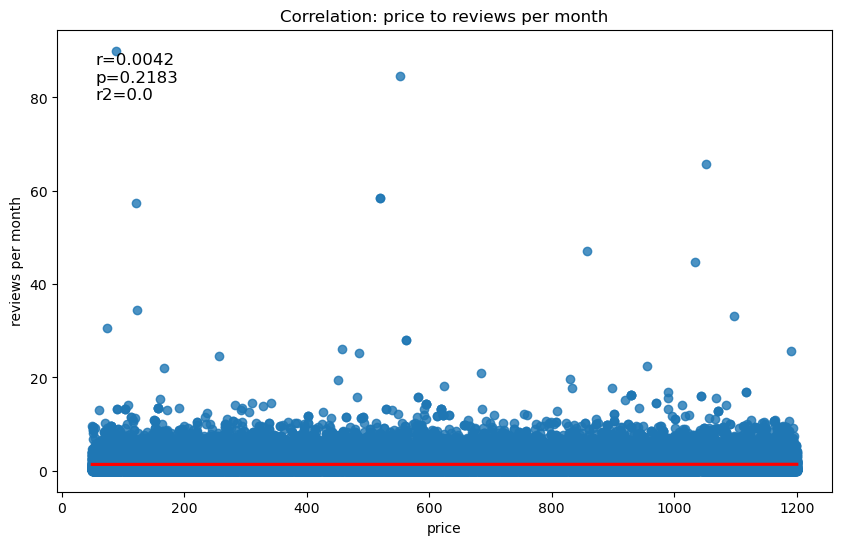

In [23]:
plt.figure(figsize=(10, 6))
ax = sns.regplot(x=joint["price"], y=joint["reviews per month"], line_kws={"color": "r"})
ax.set_title("Correlation: price to reviews per month")
text = f"""r={round(r, 4)}
p={round(p, 4)}
r2={round(r2, 4)}
"""
ax.text(0.05, 0.95, text, fontsize=12, ha="left", va="top", transform=ax.transAxes)
